# 00 · Warm-up: why $H = 1/2$ is a modelling choice

Black–Scholes, Heston, SABR: every model you have calibrated is driven by Brownian motion, and each
inherits one number from it that nobody asks you to calibrate, namely how rough the driving path is,
fixed silently at $H = 1/2$.

**The question.** What does $[W]_t = t$ assert about a path, how do you check it in ten lines of
code, and what would break if it were false?

The plan for the series is in [ROADMAP.md](ROADMAP.md). Everything here is simulated: **no market
data appears in this notebook**, and it runs top to bottom from a clean kernel with one seed, set
below.

In [1]:
import inspect
from math import gamma

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from roughvol import paths, variation
from roughvol.plotting import ACCENT, ACCENT_ALT, FIGSIZE_DIAG, FIGSIZE_WIDE, style

style()          # this repository's matplotlib defaults, applied once

SEED = 20260917  # every path in this notebook descends from this one integer

## 1. Quadratic variation, and what "rough" means

Start where the money is. Delta-hedge a European option to expiry at Black–Scholes implied
volatility $\sigma_{\text{imp}}$ while the underlying realises $\sigma_{\text{real}}$, and the
profit is

$$
\Pi_T \;=\; \tfrac{1}{2}\int_0^T \Gamma_t\, S_t^2 \left(\sigma_{\text{real},t}^2 -
\sigma_{\text{imp}}^2\right) dt ,
$$

a gamma-weighted bet on *realised variance against implied*. Three conventions do the work, and an
interviewer will ask for all three: you are **long** the option (short it and the sign flips);
$\Gamma_t$ is the *Black–Scholes* gamma at $\sigma_{\text{imp}}$, along the realised path, not the
true model's gamma; and $r = 0$. So hedged, the identity is **exact**, and we derive it below.

The part worth re-reading is $\sigma_{\text{real}}^2\,dt$: the **quadratic variation of the log
price**, the limit of a sum of squared returns as you sample more and more finely. So "how much does
this path wiggle at small scales?" is a P&L question before it is a mathematics question. If the
wiggle differs from what Brownian motion asserts, the integral above is not the number you thought
you were trading, and it may not exist at all.

### The intuition: what you see when you zoom in

Take any curve you can differentiate and zoom in on a point. It flattens: that *is* what
differentiable means, the curve becoming indistinguishable from a straight line.

A Brownian path refuses. Zoom in and you get another Brownian path, the same jagged mess at a
smaller scale. Roughness is not an adjective about how ugly the picture looks. It is the **exchange
rate between the two zooms**: shrink the horizontal axis by a factor $c$ and the vertical wiggle
shrinks only by $\sqrt{c}$. That square root is $H = 1/2$, and it is the whole subject.

The rest follows from one experiment. Take a path, look at it at three scales, then start counting:
refine the grid and total the increments two ways. One total runs away to infinity; the other
settles on $t$.

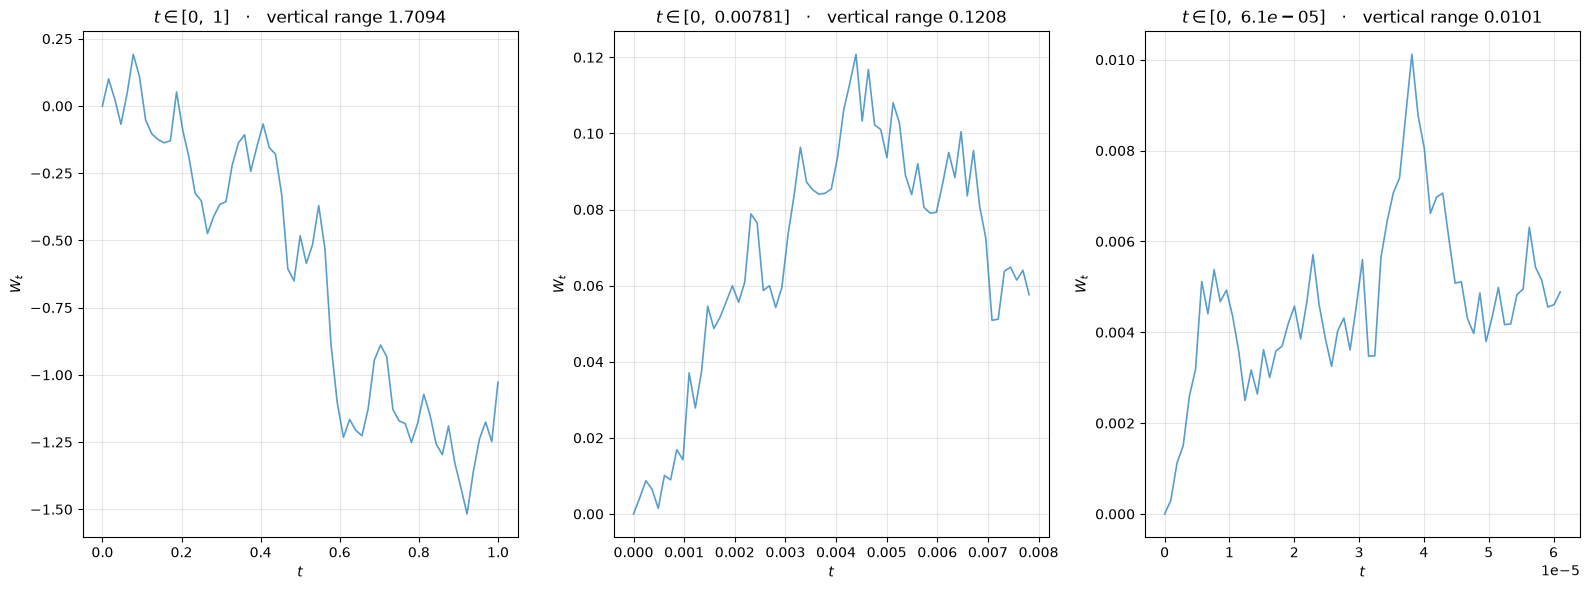

time shrinks by a factor of 128 between panels
vertical range shrinks by 14.2x then 11.9x
square root of the time zoom: sqrt(128) = 11.3


In [2]:
N_FINE = 2**20        # steps on the finest grid we will ever look at
T = 1.0
ZOOM = 2**7           # each panel zooms in by this factor in time (128x)

W = paths.brownian(n=N_FINE, T=T, m=1, seed=SEED)[0]   # one path, shape (N_FINE + 1,)
t = np.linspace(0.0, T, N_FINE + 1)                    # the matching grid

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
spans = []
for k, ax in enumerate(axes):
    width = N_FINE // ZOOM**k            # steps inside this window
    stride = width // 64                 # draw 64 segments in every panel, whatever the scale
    ts, ws = t[: width + 1 : stride], W[: width + 1 : stride]
    spans.append(np.ptp(ws))
    ax.plot(ts, ws, color=ACCENT, alpha=0.8)
    ax.set_title(f"$t \\in [0,\\ {width / N_FINE:.3g}]$   ·   vertical range {spans[-1]:.4f}")
    ax.set_xlabel("$t$")
    ax.set_ylabel("$W_t$")
fig.tight_layout()
plt.show()

print(f"time shrinks by a factor of {ZOOM} between panels")
print(f"vertical range shrinks by {spans[0] / spans[1]:.1f}x then {spans[1] / spans[2]:.1f}x")
print(f"square root of the time zoom: sqrt({ZOOM}) = {np.sqrt(ZOOM):.1f}")

**Result: you cannot tell the three panels apart.** Each shows the same number of segments from the
same path, over windows differing by a factor of 128 and then 128 again. Nothing flattens.

What *does* change is the vertical axis: a $128\times$ zoom in time costs about
$\sqrt{128} \approx 11$ in space, not $128$. That exchange rate is what we now measure.

### The experiment: count the increments two ways

Chop $[0, T]$ into $n$ equal pieces, read the same path at those $n+1$ grid points, and form two
sums from the increments $\Delta W_i = W_{t_i} - W_{t_{i-1}}$:

- the **absolute** sum $\sum_i |\Delta W_i|$, the length of the path if you unbent it;
- the **squared** sum $\sum_i (\Delta W_i)^2$.

Then double $n$ and read the *same* path more finely. Not a limit theorem yet, just a table: watch
the two columns go opposite ways.

In [3]:
print(f"{'n':>7} {'dt':>12} {'sum |dW|':>10} {'x prev':>7} {'sum dW^2':>10} {'x prev':>7}")
prev_v1 = prev_qv = None
for k in range(4, 15):
    n = 2**k
    sub = W[:: N_FINE // n]                       # the same path, read on a coarser grid
    v1 = float(variation.p_variation(sub, 1.0))   # sum |dW|
    qv = float(variation.quadratic_variation(sub))  # sum dW^2
    r1 = f"{v1 / prev_v1:7.3f}" if prev_v1 else " " * 7
    r2 = f"{qv / prev_qv:7.3f}" if prev_qv else " " * 7
    print(f"{n:>7} {T / n:12.3e} {v1:10.4f} {r1} {qv:10.4f} {r2}")
    prev_v1, prev_qv = v1, qv

      n           dt   sum |dW|  x prev   sum dW^2  x prev
     16    6.250e-02     3.0951             0.9932        
     32    3.125e-02     4.6314   1.496     1.1410   1.149
     64    1.562e-02     6.4849   1.400     0.9300   0.815
    128    7.812e-03     8.1805   1.261     0.8142   0.876
    256    3.906e-03    11.3977   1.393     0.8762   1.076
    512    1.953e-03    17.4102   1.528     0.9853   1.124
   1024    9.766e-04    25.1363   1.444     0.9823   0.997
   2048    4.883e-04    35.1687   1.399     0.9615   0.979
   4096    2.441e-04    50.2577   1.429     0.9773   1.016
   8192    1.221e-04    72.4269   1.441     0.9944   1.018
  16384    6.104e-05   102.3620   1.413     0.9962   1.002


**Result: one column parks, the other runs away.** The squared column never leaves the
neighbourhood of $1 = T$: it strays by $0.07$ to $0.19$ over $n = 32$ to $256$, and is inside half a
percent by $n = 16384$. The absolute column multiplies by about $1.41 \approx \sqrt{2}$ on
every doubling, so it grows like $\sqrt{n}$ and has no limit: this path has infinite length.

The wobble in that column is the second thing to measure, not noise to apologise for.
Refining the grid does not move where that column sits, only how tightly: step 3 below gives the
spread as $T\sqrt{2/n}$, which is $0.35$ at $n = 16$ and $0.011$ at $n = 16384$. A band describes
the distribution of the error, so no single row of the table can confirm or refute it.

The squared total is what the rest of the series cares about. It has a name, the **quadratic
variation**, written $[W]_t$, and the table shows the claim

$$[W]_t = t .$$

That is not a property of the picture and not a definition you may choose. It is a statement about a
limit of sums you can *check on a path*, which is what makes $H = 1/2$ falsifiable.

### Why, in five steps

Bookwork, derived here in full: **no paper, equation number or theorem is cited in this section,
because none is needed.** Grid $t_i = i\,T/n$, step $\Delta t = T/n$.

**1. The construction.** Brownian motion on this grid is built from independent Gaussian increments
scaled by the square root of the step,

$$\Delta W_i = \sqrt{\Delta t}\; Z_i, \qquad Z_i \stackrel{\text{iid}}{\sim} N(0,1), \qquad W_0 = 0 .$$

Summing them, $W_{t_k} = \sqrt{\Delta t}\sum_{i \le k} Z_i$, so $\operatorname{Var}(W_t) = t$:
variances add because the increments are independent, and that square root is the only scaling
under which $\operatorname{Var}(W_t)$ is free of the simulation grid.

```python
increments = np.sqrt(dt) * rng.standard_normal((m, n))
```

**2. The mean of the quadratic variation is exact, at every $n$.** Substituting step 1,

$$QV_n \;=\; \sum_{i=1}^n (\Delta W_i)^2 \;=\; \Delta t \sum_{i=1}^n Z_i^2 ,
\qquad \mathbb{E}[QV_n] \;=\; \Delta t \cdot n \cdot \mathbb{E}[Z^2] \;=\; n \,\Delta t \;=\; T .$$

This is where "it converges to $T$" is too weak. $\mathbb{E}[QV_n] = T$ is an **identity**, true at
$n = 4$ and at $n = 4$ million: nothing about the mean converges, because there is nothing for it to
converge to.

```python
qv = (np.diff(W, axis=-1) ** 2).sum(axis=-1)
```

**3. What does converge is the spread.** For $Z \sim N(0,1)$, $\mathbb{E}[Z^4] = 3$, so
$\operatorname{Var}(Z^2) = 2$, and the $Z_i$ are independent, so variances add:

$$\operatorname{Var}(QV_n) \;=\; (\Delta t)^2 \sum_{i=1}^n \operatorname{Var}(Z_i^2) \;=\;
n \cdot \frac{T^2}{n^2} \cdot 2 \;=\; \frac{2T^2}{n},
\qquad \operatorname{sd}(QV_n) \;=\; T\sqrt{\tfrac{2}{n}} .$$

So $QV_n \to T$ in $L^2$ at rate $n^{-1/2}$. That is the honest version of $[W]_t = t$, and
notebook 03's estimators live or die by it: realised variance is unbiased at any frequency, and
sampling faster buys precision, not accuracy.

**4. The same sum with a different exponent.** Replace the square by a power $p > 0$:

$$V_p(n) \;=\; \sum_{i=1}^n |\Delta W_i|^p \;=\; (\Delta t)^{p/2} \sum_{i=1}^n |Z_i|^p,
\qquad \mathbb{E}[V_p(n)] \;=\; \mu_p\, T^{p/2}\, n^{1 - p/2},$$

with $\mu_p = \mathbb{E}|Z|^p = 2^{p/2}\,\Gamma\!\left(\frac{p+1}{2}\right)/\sqrt{\pi}$ free of $n$.
The whole story is in the exponent $1 - p/2$, the log-log slope of $V_p$ against $n$:

| $p$ | slope | as $n \to \infty$ |
|---|---|---|
| $p < 2$ | $+$ | diverges (our $p=1$ column, slope $1/2$) |
| $p = 2$ | $0$ | constant at $T$ |
| $p > 2$ | $-$ | collapses to zero |

The crossover at $p = 2$ is the **$p$-variation index**, the single number this series is about.
Nothing above used the *shape* of the increment distribution, only its scale, so rerun it with
increments of size $(\Delta t)^H$:

$$V_p(n) \;\asymp\; n \cdot (\Delta t)^{pH} \;=\; T^{pH}\, n^{1 - pH},$$

flat exactly when $pH = 1$. A path of Hurst index $H$ therefore has index $1/H$: $H = 1/2$ *is*
index $2$, and $H \approx 0.1$ is index $10$, with $\sum (\Delta W)^2 \asymp n^{1-2H} = n^{0.8}
\to \infty$. Notebook 01 builds that process; this is only its scaling.

```python
v_p = (np.abs(np.diff(W, axis=-1)) ** p).sum(axis=-1)
```

**5. The same statement, read pathwise: Hölder.** Step 1 says $|\Delta W| \asymp \sqrt{\Delta t}$,
so halving the step shrinks a typical increment by $\sqrt{2}$, not by $2$, and a bound

$$|W_t - W_s| \;\le\; C\,|t - s|^{\gamma}$$

can hold for every $\gamma < 1/2$ but fails at $\gamma = 1/2$. The difference quotient is
$\Delta W / \Delta t \asymp (\Delta t)^{-1/2} \to \infty$, so there is no derivative anywhere,
which is why nothing flattened in the zoom plot. Roughness, index and Hölder exponent are three
readings of one fact: $\gamma = H = 1/p$.

### 6. What it buys: Itô's formula and the gamma P&L

Itô's formula, for $f(t, X_t)$ with $X$ a continuous semimartingale, has **three** terms, not two:

$$df \;=\; \frac{\partial f}{\partial t}\,dt \;+\; \frac{\partial f}{\partial x}\,dX \;+\;
\tfrac{1}{2}\frac{\partial^2 f}{\partial x^2}\,d[X] .$$

The last term is quadratic variation and nothing else, and it is all we need to derive the hook's
identity. Apply Itô to the value $f(t, S_t)$ of a European option priced at $\sigma_{\text{imp}}$,
with $\theta_t, \Delta_t, \Gamma_t$ its Black–Scholes derivatives:

$$df \;=\; \theta_t\,dt \;+\; \Delta_t\,dS_t \;+\; \tfrac{1}{2}\Gamma_t\,d[S]_t .$$

1. Hold $-\Delta_t$ shares against the option: the $\Delta_t\,dS_t$ term cancels by construction,
   so the directional bet is gone and two terms survive.
2. $f$ solves the Black–Scholes PDE at $\sigma_{\text{imp}}$, so at $r = 0$ the theta leg is
   $\theta_t = -\tfrac{1}{2}\sigma_{\text{imp}}^2 S_t^2 \Gamma_t$. *Implied* variance enters here,
   through theta and the PDE, never through $d[S]$.
3. The realised leg is $d[S]_t = \sigma_{\text{real},t}^2 S_t^2\,dt$. Adding the two survivors,

$$d\Pi_t \;=\; \tfrac{1}{2}\Gamma_t S_t^2\left(\sigma_{\text{real},t}^2 -
\sigma_{\text{imp}}^2\right) dt ,$$

which integrates to the hook's $\Pi_T$, and which checkpoint (iii) below asks you to reproduce.

Step 3 is where this section's subject enters the P&L: $(dS)^2 = \sigma^2 S^2\,dt$ *is* the
quadratic-variation statement, $[W]_t = t$ in the units of a price, and the only route by which the
realised path reaches the profit.

### Move the index off 2 and watch what breaks

Three regimes, as a teaser; notebook 01 makes the semimartingale argument properly.

- **Index exactly $1$** (finite variation: a smooth path, or any path of bounded variation). It is
  a semimartingale, so Itô applies, but $[X] = 0$ and the formula collapses to the ordinary chain
  rule. No second-order term, so no gamma P&L: what dies is the trade, not the theorem.
- **Index strictly between $1$ and $2$**, for instance fractional Brownian motion with
  $H \in (1/2, 1)$, smoother than Brownian. Here $[X] = 0$ *and* the total variation is infinite,
  and that pair is fatal. A continuous semimartingale with zero quadratic variation has a constant
  local-martingale part, hence is of finite variation, contradicting infinite total variation. So
  such a path is not a semimartingale at all, and there is no Itô integral to write against it. (A
  pathwise chain rule survives, in Föllmer's sense, but pricing theory is not built on it.)
- **Index above $2$**: fBm with $H < 1/2$, the rough case this series is about. Sums of squared
  increments diverge, so there is no finite $[X]$ to integrate against, and again the path is not a
  semimartingale.

So $2$ is the **only** index at which Itô calculus applies *and* leaves a non-trivial second-order
term, and smoother is not safer: $H = 0.8$ (index $1.25$) is as far outside the theory as $H = 0.1$
(index $10$). Hence the title of this notebook.

A **semimartingale** is a local martingale plus a finite-variation piece, the decomposition that
builds the integrals above; until notebook 01's primer, read it as "a process Itô's formula applies
to". (Rough *volatility* moves the index of the volatility, not of the price, which stays a
semimartingale: notebook 04's job.)

In [4]:
print(inspect.getsource(paths.brownian))

def brownian(n: int, T: float, m: int, seed: int) -> np.ndarray:
    """Simulate standard Brownian motion on a uniform grid.

    Builds m independent paths of W on the grid t_i = i * T / n, i = 0..n, from
    iid Gaussian increments

        W_{t_i} - W_{t_{i-1}} = sqrt(dt) * Z_i,    Z_i ~ N(0, 1),  dt = T / n,

    so E[W_t] = 0, Var(W_t) = t, and increments over disjoint intervals are
    independent. Every identity in notebook 00 rests on that independence.

    Shape convention, fixed here and followed by every simulator in this
    package: the returned array has shape (m, n + 1) and column 0 is the t = 0
    value, identically 0.0. So W[:, -1] is W_T, W.shape[1] - 1 is the number of
    steps, and the matching time grid is np.linspace(0.0, T, n + 1).

    Parameters
    ----------
    n : int
        Number of steps, n >= 1; the grid has n + 1 points.
    T : float
        Horizon, T > 0.
    m : int
        Number of independent paths, m >= 1.
    seed : int
        Seed for nu

That is the whole simulator. Line by line, because three of these choices are conventions the rest
of the series depends on:

- `rng = np.random.default_rng(seed)` is a **local** generator, not `np.random.seed`. One seed in,
  one array out, bit for bit, whatever else has drawn random numbers first. Every simulator in
  `roughvol` takes `seed: int` and does this, which is why the widget below is reproducible.
- `increments = np.sqrt(dt) * rng.standard_normal((m, n))` is step 1, verbatim. The
  $\sqrt{\Delta t}$ lives here, the only place roughness enters: replace it with $(\Delta t)^H$,
  correlate the draws, and you have fractional Brownian motion.
- `W = np.empty((m, n + 1))`, `W[:, 0] = 0.0`, `np.cumsum(..., out=W[:, 1:])` fix the **shape
  convention for the whole package**: paths come back as `(m, n + 1)` with column 0 the $t = 0$
  value, identically zero. So `W[:, -1]` is $W_T$, `np.linspace(0.0, T, n + 1)` is the matching
  grid, and nothing later guesses whether time starts at 0 or at $\Delta t$.
- `np.cumsum`, not a Python loop: the path *is* the running sum of its increments, which is what
  makes the $n = 2^{20}$ above cheap.

In [5]:
print(inspect.getsource(variation.quadratic_variation))
print(inspect.getsource(variation.p_variation))

def quadratic_variation(path: np.ndarray, running: bool = False) -> np.ndarray:
    """Realised quadratic variation of a sampled path, on its own grid.

    For a path sampled at t_0 < ... < t_n,

        QV_n = sum_{i=1}^{n} (X_{t_i} - X_{t_{i-1}})**2,

    the p = 2 case of `p_variation`. For Brownian motion on a uniform grid of n
    steps over [0, T] it is exact in the mean and converges in L^2:

        E[QV_n] = T   for every n,        Var(QV_n) = 2 * T**2 / n,

    because each squared increment is dt * Z**2 with Z ~ N(0, 1), E[Z**2] = 1
    and Var(Z**2) = 2. One path's QV therefore sits within about T*sqrt(2/n) of
    T: the rate is n**(-1/2).

    Parameters
    ----------
    path : numpy.ndarray
        Sampled path(s); last axis is time, at least 2 points. Shape (m, n + 1)
        as returned by `roughvol.paths.brownian`, or (n + 1,).
    running : bool, default False
        If True, return the cumulative sum rather than the total: realised
        [X]_t at each grid poin

Both functionals are two lines of numpy wrapped in a docstring, and the two lines are the two sums
from the table:

- `np.diff(path, axis=-1)` differences along the **last** axis, which is why one function serves a
  single path of shape `(n + 1,)` and a stack of shape `(m, n + 1)` without a branch. The output has
  `n` entries: $n+1$ grid points, $n$ increments.
- `** 2` then `np.sum(..., axis=-1)` for the quadratic variation; `np.abs(...) ** p` then the same
  sum in general. `quadratic_variation` is genuinely the $p = 2$ case of `p_variation`, and a test
  asserts they agree to machine precision, so the duplication cannot drift.
- `running=True` returns `np.cumsum` instead of `np.sum`: realised $[X]_t$ at each grid point,
  which the plots below draw against $t$.

**One caveat, and it is not pedantry.** The textbook $p$-variation is a *supremum over all
partitions*, not a sum over the grid you hold, and the two differ even at $p = 2$: for Brownian
motion $\sup_\pi \sum (\Delta W)^2$ is almost surely infinite, and finite only for $p > 2$: index
$2$ is the critical exponent at which the supremum still fails. What is finite is the **grid** sum
in the mesh-to-zero limit, which for a continuous semimartingale converges to $[X]_t$. Hence quadratic variation is an exponent one can *measure*, which is what a
realised-variance estimator does with five-minute bars.

### Check the two identities numerically

Steps 2 and 3 say something sharp enough to be wrong: $\mathbb{E}[QV_n] = T$ exactly, with standard
deviation $T\sqrt{2/n}$. Simulate an ensemble and compare. The Monte Carlo error on the
mean is $\widehat{\text{SE}} = \operatorname{sd}(QV)/\sqrt{m}$, so a deviation inside
$4\,\widehat{\text{SE}}$ is a pass: quote the band, not just the number.

In [6]:
M, N = 200, 4096
ens = paths.brownian(n=N, T=T, m=M, seed=SEED + 1)
qv = variation.quadratic_variation(ens)
se = qv.std(ddof=1) / np.sqrt(M)

print(f"mean QV over {M} paths : {qv.mean():.5f}        theory T           = {T:.5f}")
print(f"  relative error       : {qv.mean() / T - 1:+.3%}")
print(f"  deviation / 4*SE     : {abs(qv.mean() - T) / (4 * se):.2f}   (pass if < 1)")
s, s_theory = qv.std(ddof=1), T * np.sqrt(2 / N)
se_s = s / np.sqrt(2 * (M - 1))   # standard error of a Gaussian sd estimate
print(f"sd(QV)                 : {s:.5f}        theory T*sqrt(2/n) = {s_theory:.5f}")
print(f"  deviation / 4*SE     : {abs(s - s_theory) / (4 * se_s):.2f}   (pass if < 1)")
var_T = ens[:, -1].var(ddof=1)
se_v = var_T * np.sqrt(2 / (M - 1))   # standard error of a Gaussian variance estimate
print(f"Var(W_T)               : {var_T:.5f}        theory T           = {T:.5f}")
print(f"  deviation / 4*SE     : {abs(var_T - T) / (4 * se_v):.2f}   (pass if < 1)")

mean QV over 200 paths : 0.99952        theory T           = 1.00000
  relative error       : -0.048%
  deviation / 4*SE     : 0.08   (pass if < 1)
sd(QV)                 : 0.02069        theory T*sqrt(2/n) = 0.02210
  deviation / 4*SE     : 0.34   (pass if < 1)
Var(W_T)               : 1.00770        theory T           = 1.00000
  deviation / 4*SE     : 0.02   (pass if < 1)


**Result: the quadratic variation is unbiased at every $n$, and what shrinks with $n$ is its
spread.** The mean sits on $T$ a small fraction of its band away, and the sample standard deviation
sits on $T\sqrt{2/n}$ inside *its* wider band: an estimated standard deviation from $m$ paths
carries its own error of about $s/\sqrt{2(m-1)}$. As a hedging statement: hourly and five-minute
samplers estimate the same realised variance on average, the faster one with a tighter distribution
around it.

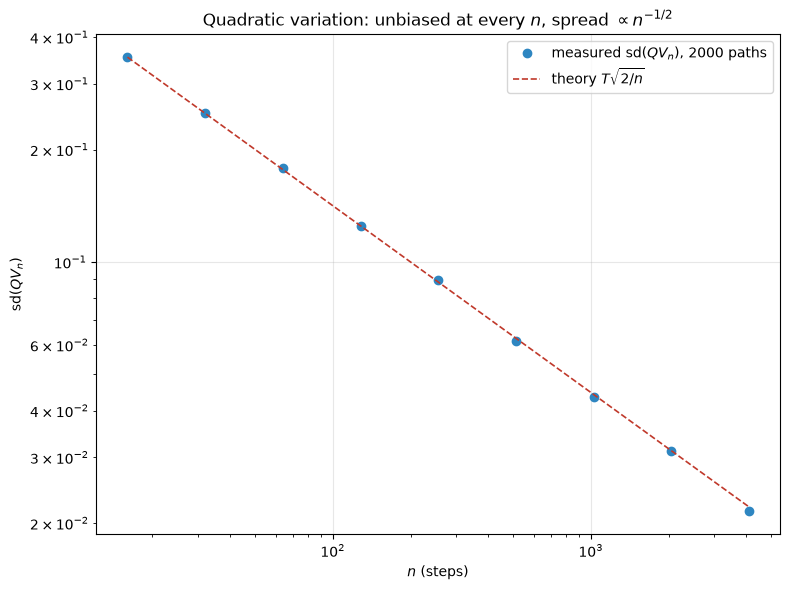

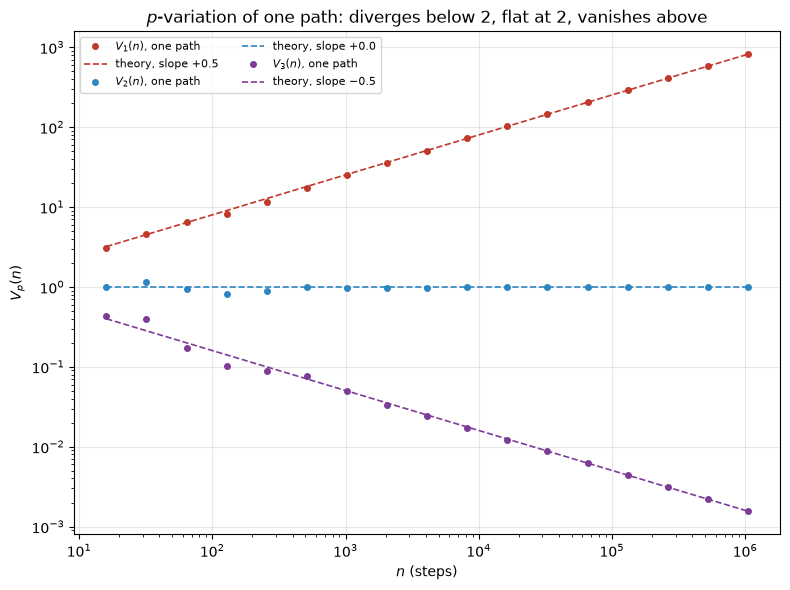

In [7]:
# Diagnostic 1: the spread of QV falls like n^{-1/2}
ns = 2 ** np.arange(4, 13)
sds = [
    variation.quadratic_variation(
        paths.brownian(n=int(n), T=T, m=2000, seed=SEED + 100 + i)
    ).std(ddof=1)
    for i, n in enumerate(ns)
]

fig, ax = plt.subplots(figsize=FIGSIZE_DIAG)
ax.loglog(ns, sds, "o", color=ACCENT, label="measured sd($QV_n$), 2000 paths")
ax.loglog(ns, T * np.sqrt(2 / ns), "--", color=ACCENT_ALT, label=r"theory $T\sqrt{2/n}$")
ax.set_xlabel("$n$ (steps)")
ax.set_ylabel("sd($QV_n$)")
ax.set_title("Quadratic variation: unbiased at every $n$, spread $\\propto n^{-1/2}$")
ax.legend()
fig.tight_layout()
plt.show()

# Diagnostic 2: the same path summed with three different exponents
ns_p = 2 ** np.arange(4, 21)
fig, ax = plt.subplots(figsize=FIGSIZE_DIAG)
for p, colour in zip((1.0, 2.0, 3.0), (ACCENT_ALT, ACCENT, "#7D3C98"), strict=True):
    measured = [float(variation.p_variation(W[:: N_FINE // int(n)], p)) for n in ns_p]
    mu_p = 2 ** (p / 2) * gamma((p + 1) / 2) / np.sqrt(np.pi)
    ax.loglog(ns_p, measured, "o", ms=4, color=colour, label=f"$V_{{{p:.0f}}}(n)$, one path")
    ax.loglog(ns_p, mu_p * T ** (p / 2) * ns_p ** (1.0 - p / 2), "--", color=colour,
              label=f"theory, slope ${1 - p / 2:+.1f}$")
ax.set_xlabel("$n$ (steps)")
ax.set_ylabel("$V_p(n)$")
ax.set_title("$p$-variation of one path: diverges below 2, flat at 2, vanishes above")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

**Result: Brownian motion has $p$-variation index 2, and $p = 2$ is the only exponent whose sum
converges to something finite and non-zero.** The first plot puts the measured spread of $QV_n$ on
$T\sqrt{2/n}$ over eight octaves: the $n^{-1/2}$ rate, with no fitted parameter. The second sums a
*single* path three ways: $p = 1$ climbs the predicted slope $+1/2$, $p = 2$ is flat at $T = 1$
across sixteen doublings, $p = 3$ falls away at $-1/2$. The dashed lines are
$\mu_p T^{p/2} n^{1-p/2}$ from step 4: theory, not a regression.

Hold that flat middle line: notebook 01 draws it again for $H = 0.1$, where it sits at $p = 10$.

### Feel it move

One slider for the grid, one for the seed. Watch the running quadratic variation $[W]_t$ against the
line $y = t$: coarse grids wander, fine grids hug it, no grid moves it.

*The widget needs a running kernel; on GitHub it is an empty box, and the next cell draws it
statically.*

In [8]:
def running_qv_view(log2n: int, seed: int) -> None:
    """Draw one path and its running quadratic variation on a grid of 2**log2n steps."""
    n = 2**log2n
    w = paths.brownian(n=n, T=T, m=1, seed=seed)[0]
    grid = np.linspace(0.0, T, n + 1)

    fig, (ax_path, ax_qv) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
    ax_path.plot(grid, w, color=ACCENT, alpha=0.8)
    ax_path.set_title(f"path, $n = {n}$ steps (seed {seed})")
    ax_path.set_xlabel("$t$")
    ax_path.set_ylabel("$W_t$")

    qv_t = variation.quadratic_variation(w, running=True)
    ax_qv.plot(grid[1:], qv_t, color=ACCENT, alpha=0.8, label=r"running $[W]_t$")
    ax_qv.plot(grid, grid, "--", color=ACCENT_ALT, label="$y = t$")
    ax_qv.set_title(f"realised $[W]_T$ = {qv_t[-1]:.3f}   vs   $T$ = {T:.3f}")
    ax_qv.set_xlabel("$t$")
    ax_qv.set_ylabel(r"$[W]_t$")
    ax_qv.legend()
    fig.tight_layout()
    plt.show()


_ = widgets.interact(
    running_qv_view,
    log2n=widgets.IntSlider(min=4, max=12, value=8, description="log2 n"),
    seed=widgets.IntSlider(min=0, max=9, value=0, description="seed"),
)

interactive(children=(IntSlider(value=8, description='log2 n', max=12, min=4), IntSlider(value=0, description=…

The static version, for readers on GitHub: three panels, three grids. Unlike the slider, which
draws an independent path each time, all three read the *same* path at $n = 2^6$, $2^9$ and
$2^{12}$, so only the sampling frequency changes.

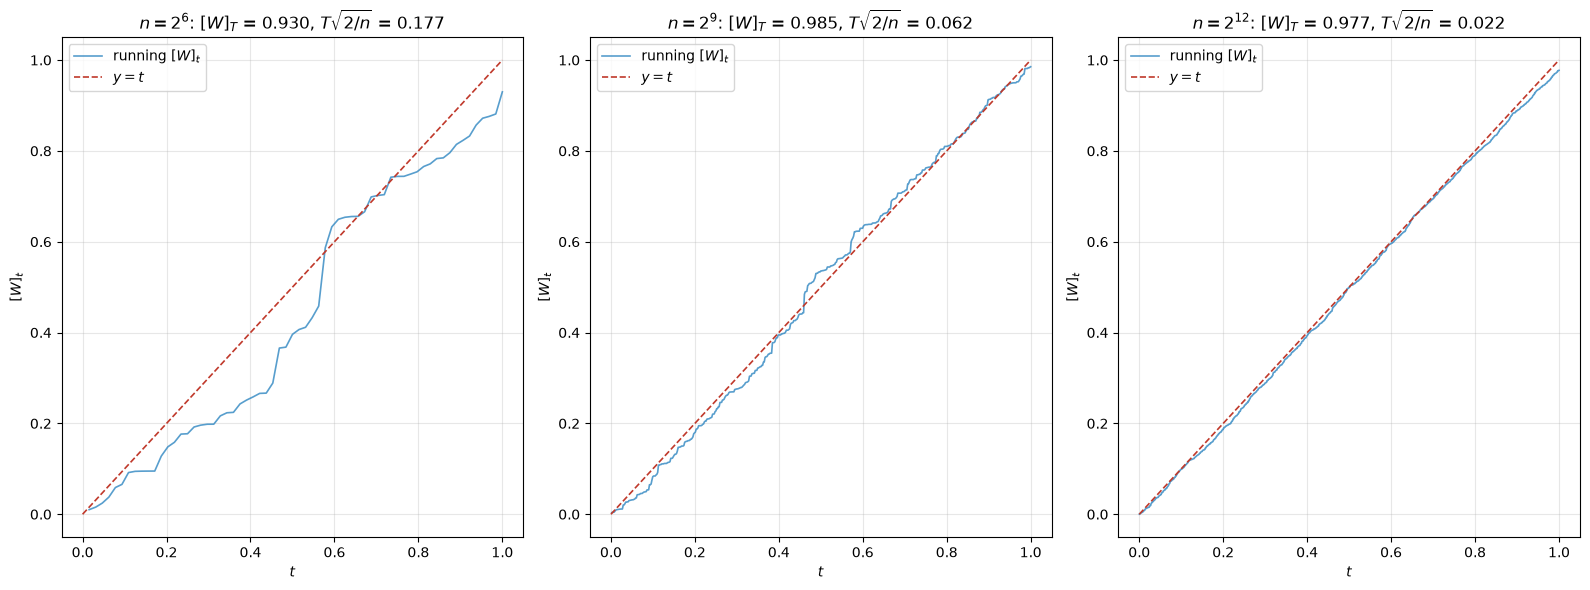

In [9]:
# Static fallback: one path, three grids, nested so it is literally the same path read more finely
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
for ax, k in zip(axes, (6, 9, 12), strict=True):
    n = 2**k
    sub = W[:: N_FINE // n]
    grid = np.linspace(0.0, T, n + 1)
    qv_t = variation.quadratic_variation(sub, running=True)
    ax.plot(grid[1:], qv_t, color=ACCENT, alpha=0.8, label=r"running $[W]_t$")
    ax.plot(grid, grid, "--", color=ACCENT_ALT, label="$y = t$")
    band = T * np.sqrt(2 / n)
    ax.set_title(f"$n = 2^{{{k}}}$: $[W]_T$ = {qv_t[-1]:.3f}, $T\\sqrt{{2/n}}$ = {band:.3f}")
    ax.set_xlabel("$t$")
    ax.set_ylabel(r"$[W]_t$")
    ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**Result: refining the grid changes how tightly the running $[W]_t$ tracks $t$, not where it goes.**
At $n = 2^6$ the realised variance strays visibly from the diagonal and lands at $0.930$, against a
band $T\sqrt{2/n} = 0.177$; at $n = 2^{12}$ it lands at
$0.977$ against a band of $0.022$ and tracks the line the whole way. Neither miss is remarkable: the
band itself shrank eightfold. Unbiased everywhere, precise only when you look often.

### Whiteboard checkpoint

Close the notebook and answer these aloud. If an answer needs the screen, the section has not landed
yet.

**(i)** Why is $\mathbb{E}[QV_n] = T$ for *every* $n$, and what is it that actually converges as
$n \to \infty$?

<details>
<summary>Worked answer</summary>

Write $\Delta W_i = \sqrt{\Delta t}\,Z_i$ with $Z_i$ iid standard normal and $\Delta t = T/n$. Then
$QV_n = \Delta t \sum_{i=1}^n Z_i^2$, so

$$\mathbb{E}[QV_n] = \Delta t \cdot n \cdot \mathbb{E}[Z^2] = n \cdot \frac{T}{n} \cdot 1 = T .$$

Every $n$, exactly: an algebraic identity, not a limit, and it uses only $\mathbb{E}[Z^2] = 1$, not
independence. What converges is the **variance**: independence gives
$\operatorname{Var}(QV_n) = n (\Delta t)^2 \operatorname{Var}(Z^2) = 2T^2/n \to 0$, using
$\operatorname{Var}(Z^2) = \mathbb{E}[Z^4] - 1 = 2$, so $QV_n \to T$ in $L^2$ at rate $n^{-1/2}$.
The trap is to say "$QV_n$ converges to $T$ as the mesh goes to zero" and hide that there is no bias
to shrink.

</details>

**(ii)** $\sum_i |\Delta W_i| \to \infty$ while $\sum_i (\Delta W_i)^2 \to t$. What does that pair of
facts say about the Hölder exponent of the path, and what changes at $H = 0.1$?

<details>
<summary>Worked answer</summary>

Both come from one scaling, $|\Delta W_i| \asymp (\Delta t)^{1/2}$: summing $n$ terms of size
$(\Delta t)^{p/2}$ gives $V_p(n) \asymp n^{1-p/2}$, so the crossover $p = 2$ is the index. Pathwise
the same scaling makes $|W_t - W_s| \le C|t-s|^{\gamma}$ hold for every $\gamma < 1/2$ and fail at
$\gamma = 1/2$, so there is no derivative anywhere.

At $H = 0.1$ increments scale as $(\Delta t)^{0.1}$, so $\sum (\Delta W)^2 \asymp n^{1 - 2H} =
n^{0.8} \to \infty$: **the quadratic variation is infinite**, the index is $1/H = 10$, the Hölder
exponent is $0.1$. Such a process is not a semimartingale, so there is no Itô calculus for it and no
$\tfrac{1}{2}f''\,d[X]$ term to write down. Which is why rough volatility puts $H \approx 0.1$ on
the *volatility* and leaves the price at $H = 1/2$.

</details>

**(iii)** Start from Itô's formula and derive the delta-hedged P&L identity of the hook. At which
step does quadratic variation enter, and why is the P&L nevertheless *not* a function of $[S]_T$
alone?

<details>
<summary>Worked answer</summary>

Itô on the option value $f(t, S_t)$, priced at $\sigma_{\text{imp}}$, gives
$df = \theta_t\,dt + \Delta_t\,dS + \tfrac{1}{2}\Gamma_t\,d[S]$. Holding $-\Delta_t$ shares removes
$\Delta_t\,dS$ by construction. The Black–Scholes PDE at $\sigma_{\text{imp}}$ fixes the first
survivor: at $r = 0$, $\theta_t = -\tfrac{1}{2}\sigma_{\text{imp}}^2 S_t^2 \Gamma_t$. The second is
$\tfrac{1}{2}\Gamma_t\,d[S] = \tfrac{1}{2}\Gamma_t S_t^2 \sigma_{\text{real},t}^2\,dt$, and that is
where quadratic variation enters: $d[S] = \sigma_{\text{real}}^2 S^2\,dt$ is the only place the
realised path is read. Adding the two leaves

$$\tfrac{1}{2}\Gamma_t S_t^2\left(\sigma_{\text{real},t}^2 - \sigma_{\text{imp}}^2\right) dt ,$$

realised variance against implied, gamma-weighted, the implied leg arriving from theta via the PDE
rather than from $d[S]$.

As for the second half: $\Gamma_t S_t^2$ is a functional of the *trajectory*,
so two paths delivering the same $[S]_T$ do **not** pay the hedger the same: variance realised near
the strike, where gamma is large, pays far more than the same variance realised far away. The
instrument whose payoff is the *unweighted* realised variance
$\int_0^T \sigma_{\text{real},t}^2\,dt = [\log S]_T$ — the same integral with the dollar
gamma $\Gamma_t S_t^2$ held constant, which is what the log contract does — is the variance
swap.

</details>